### Multivariate Hypothesis Testing with Membership Circuits

A guided tour through the world of hypothesis testing and what $p$-values tell us about our models. We will see what constitutes a test, how testing in univariate, mixture, and joint distributions works, and how these results can be used to assess the quality of our models and select the best one among a set of candidates.

#### Table of Content:
* [What is Hypothesis Testing?](#introduction)
* [Testing for Membership](#testing-membership)
* [Testing in an univariate distribution](#testing-univariate)
* [Testing in Mixture Models](#testing-mixtures)
* [Testing in Fully Factorized Models](#testing-factorized)
* [Multivariate Testing with PCs](#testing-pcs)
* [The relationship of $\alpha$ and the FPR as a measure of model quality](#model-quality)

In [1]:
# Setup
import numpy as np
from matplotlib import pyplot as plt
import scienceplots
from scipy.stats import norm, multinomial, hmean
from scipy.optimize import root_scalar
from sklearn.metrics import confusion_matrix
from functools import cache

plt.style.use(["science", "no-latex"])
plt.rcParams.update({
    "text.usetex": False,
})

#### What is Hypothesis Testing? <a class="anchor" id="introduction"></a>

A *hypothesis test* is a statistical inference method. To carry out a test, we need to define a *null hypothesis*. Given a null hypothesis, we can test if observations condradict our hypothesis. The neat thing about tests is that **they allow us to bound the *False Positive Rate*** (FPR; also called Type 1 Error).
Let's see all steps to conduct a hypothesis test:
1. Define a testable null hypothesis $H_0$, e.g. $H_0: \mu=\mu_0$ or $H_0: F\geq G$
2. Select a hypothesis test that can assess $H_0$
3. Set the test niveau $\alpha$, which represents your acceptable upper bound on the FPR
4. The test will be carried out w.r.t. a test statistic. Derive the distribution $T$ of the test statistic $t$ (e.g. Student's $t$-distribution for the $t$-test)
5. Compute the test statistic $t_x$ w.r.t. your observation $x$
6. Compute the $p$-value of the test by evaluating $t_x$ in the distribution of $T$: e.g. for a left-sided test, compute $\hat{p}_T(x)=\mathbb{P}_T(T\leq t_x | H_0)$. The $p$-value is the probability of observing a value at least as extreme as $t$ (hence $x$, as $x$ is a transformation of $t$), given that $H_0$ is true.
7. If $\hat{p}_T(X)\leq \alpha$, reject $H_0$. If not, we cannot make a statement about $H_0$, except *not* rejecting it. However, following Fisher, the magnitude of the $\hat{p}$ is an indicator of "how strongly" we reject $H_0$ (and we may argue that a high $\hat{p}$ is an indicator for the fit of $H_0$. However, from a statistical point of view, we are not allowed to use this quantity for inference).

There exist families of tests for different goals, most common are (note that equalities can also be replaced by inequalities):
- One-sample tests: Determine if one set of observations $X$ comes from a hypothesized distribution with known parameter $\theta_{0}$, e.g. $H_0: \theta_X=\theta_{0}$
- Two sample tests: Determine if two sets of observations $X$ and $Y$ come from the same underlying population, e.g. $H_0: \theta_X = \theta_Y$
- Independence tests: Determine if two set of observations are statistically independent, e.g. $H_0: X \perp Y$

#### Testing for Membership <a class="anchor" id="testing-membership"></a>

Given a distribution $\mathbb{P}_X$ of a random variable $X$, and an observation $x$, we want to evaluate the hypothesis:
$$ H_0: x \sim \mathbb{P}_X $$

(Memo: derive this properly using a probability space $\mathcal{M}=(\Omega, \mathcal{F}, \mathbb{P})$ and the push-forward measure $\mathbb{P}_X$, which induces the PDF $p_X$ and the CDF $F_X$)

As we want to evaluate $x$ in a known distribution $\mathbb{P}_X$, the test distribution is the induced cumulative distribution function (CDF) $F_X$. The test statistic is $x$ itself.  So, given a left-sided test, we will asses the null hypothesis as 
$$\hat{p}_X(x)=F_X(x)=\mathbb{P}_X(X \leq x | H_0) = \mathbb{P}_T(T\leq t|H_0) \text{, with } T=X, t=x$$

We will reject $H_0$, e.g. say that $x \not\sim \mathbb{P}_X$, if $\hat{p}_X(x) \leq \alpha$.

#### Testing in a single univariate distribution <a class="anchor" id="testing-univariate"></a>

Let's take a look at the trivial case, which is depicted in the next figure: 
We assume a standard Gaussian distribution, $X \sim \mathcal{N}(\mu=0, \sigma=1)$. We also assume a two-sided test with test niveau of $\alpha=0.05$. We can compute $p$-values of observed data points $x$ within the model as 
$$\hat{p}_X(x) = 2 \min (\mathbb{P}_X(X\geq x|H_0), \mathbb{P}_X(X\leq x|H_0)) = 2 \min (F_X(x), 1 - F_X(x))$$  
We will reject that a data point stems from the known distribution if $\hat{p}_X(x) \leq \alpha$. This *rejection region* is depicted as the yellow-colored tails of the distributions. If we are given an infinite number of samples of the true distribution and test them in our model, this means that we will falsely declare $5\%$ of the samples as out-of-distribution (OOD), which is exactly our $\alpha$.

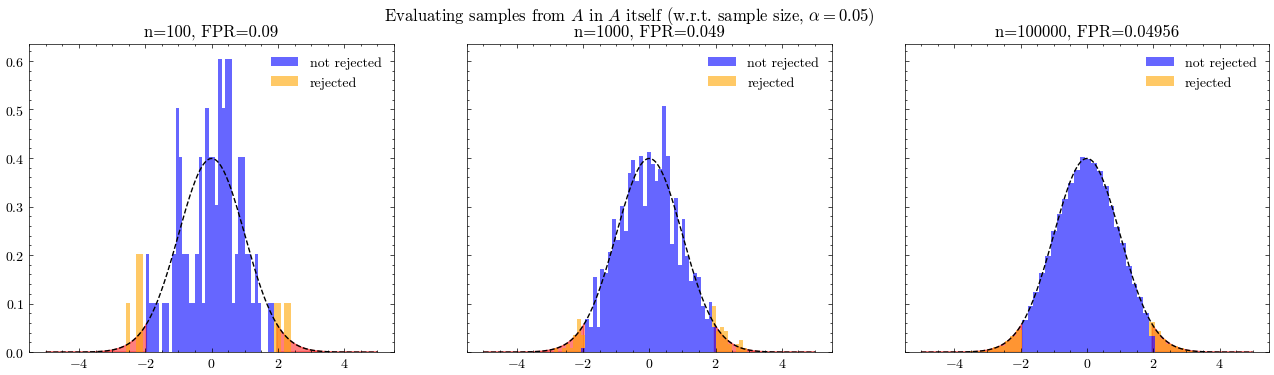

In [2]:
def twosided_test_single_univariate_symmetric(distribution, data):
    tail_probabilities = distribution.cdf(x=data)
    pvalues = 2 * np.minimum(tail_probabilities, 1.0 - tail_probabilities)
    return pvalues

def plot_gaussian(distribution, alpha, n_samples, seed=47):
    rejection_threshold = [distribution.mean() - 1.96*distribution.std(), distribution.mean() + 1.96*distribution.std()]

    k = len(n_samples)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-5.0, stop=5.0, num=1000)

    for sample_size, ax in zip(n_samples, axes):
        gaussian_density = distribution.pdf(x=x)
        ax.plot(x, gaussian_density, color="black", linestyle="--")
        ax.fill_between(x=x, y1=np.zeros_like(x), y2=gaussian_density, where=[not rejection_threshold[0]<=_<=rejection_threshold[1] for _ in x], alpha=0.5, color="red")

        gaussian_samples = distribution.rvs(size=sample_size, random_state=seed)
        pvalues = twosided_test_single_univariate_symmetric(distribution=distribution, data=gaussian_samples)
        out_of_distribution_mask = pvalues <= alpha
        ax.hist(x=[gaussian_samples[~out_of_distribution_mask], gaussian_samples[out_of_distribution_mask]], bins=50, color=["blue", "orange"], stacked=True, alpha=0.6, density=True, label=["not rejected", "rejected"])

        false_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / sample_size
        ax.set_title(rf"n={sample_size}, FPR={false_positive_rate}")

        ax.legend()

    fig.suptitle(f"Evaluating samples from $A$ in $A$ itself (w.r.t. sample size, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

gaussian = norm(loc=0.0, scale=1.0)
plot_gaussian(gaussian, alpha=0.05, n_samples=[100, 1000, 100000])

We can see that the FPR converges against $\alpha$ in the limit of the sample size. We can also see that for a low sample size, the FPR is more likely to exceed $\alpha$. This follows from the nature of frequentist statistics; and can be counteracted by increasing the variance of the model (similar to choosing a Student $t$ vs a Gaussian distribution).  

Now let us call the Standard Gaussian distribution $A$ and let us assume this is our "true" distribution $T=A$. Let us also introduce a second distribution $B$, which has a higher mean than $A$, e.g. $B \sim \mathcal{N}(\mu_B>\mu_A, \sigma_B=\sigma_A)$. Now that we have two distributions, we can assess samples from $B$ in the model of $A$, and we can compute the Power (= True Positive Rate = Sensitivity) of our test. Let's see how this turns out for different shifts of the mean:

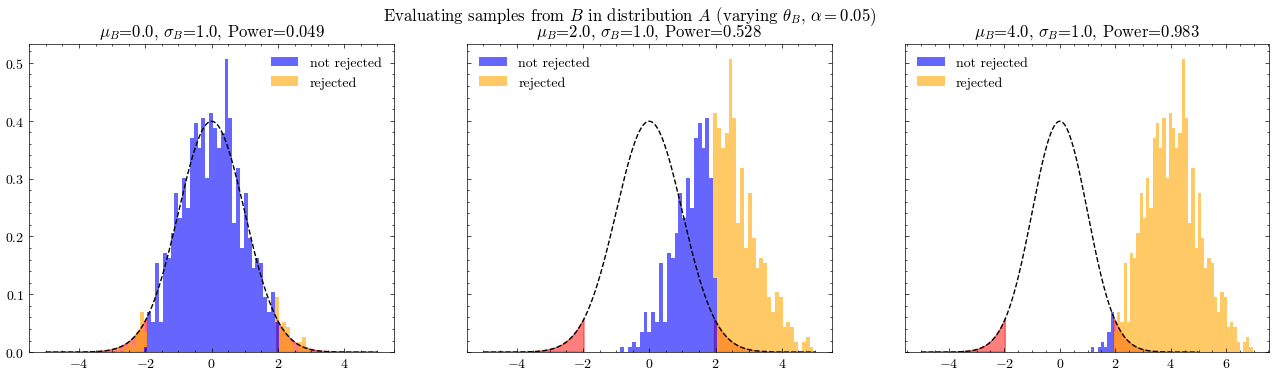

In [3]:
def plot_gaussian_b_in_a(mu_b, sigma_b, alpha, mu_a=0.0, sigma_a=1.0, n_samples=1000, seed=47):
    assert isinstance(mu_b, list) and isinstance(sigma_b, list) and len(mu_b) == len(sigma_b)
    gaussian_a = norm(loc=mu_a, scale=sigma_a)
    gaussian_b_collection = [norm(loc=m, scale=s) for (m, s) in zip(mu_b, sigma_b)]
    rejection_threshold = mu_a+1.96*sigma_a

    k = len(gaussian_b_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-5.0, stop=5.0, num=1000)

    for gaussian_b, ax in zip(gaussian_b_collection, axes):
        density_a = gaussian_a.pdf(x=x)
        ax.plot(x, density_a, color="black", linestyle="--")
        ax.fill_between(x=x, y1=np.zeros_like(x), y2=density_a, where=np.abs(x)>=rejection_threshold, alpha=0.5, color="red")

        samples_b = gaussian_b.rvs(size=n_samples, random_state=seed)
        pvalues = twosided_test_single_univariate_symmetric(distribution=gaussian_a, data=samples_b)
        out_of_distribution_mask = pvalues <= alpha
        ax.hist(x=[samples_b[~out_of_distribution_mask], samples_b[out_of_distribution_mask]], bins=50, color=["blue", "orange"], stacked=True, alpha=0.6, density=True, label=["not rejected", "rejected"])

        true_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / n_samples
        ax.set_title(rf"$\mu_B$={gaussian_b.mean()}, $\sigma_B$={gaussian_b.std()}, Power={true_positive_rate}")

        ax.legend()

    fig.suptitle(f"Evaluating samples from $B$ in distribution $A$ (varying $\\theta_B$, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

plot_gaussian_b_in_a(mu_b=[0.0, 2.0, 4.0], sigma_b=[1.0, 1.0, 1.0], alpha=0.05)

Note that the FPR=0 in all 3 examples above, as we only evaluate the "new" distribution in the "true" distribution here. We can see that the Power (the True Positive Rate) increases as the difference between the means grows larger. If the distributions are very close to each other, it becomes obviously hard to detect significant differences.  

Next, let's see what happens when we fix the means ($\mu_A=\mu_B$) and only vary the standard deviations.

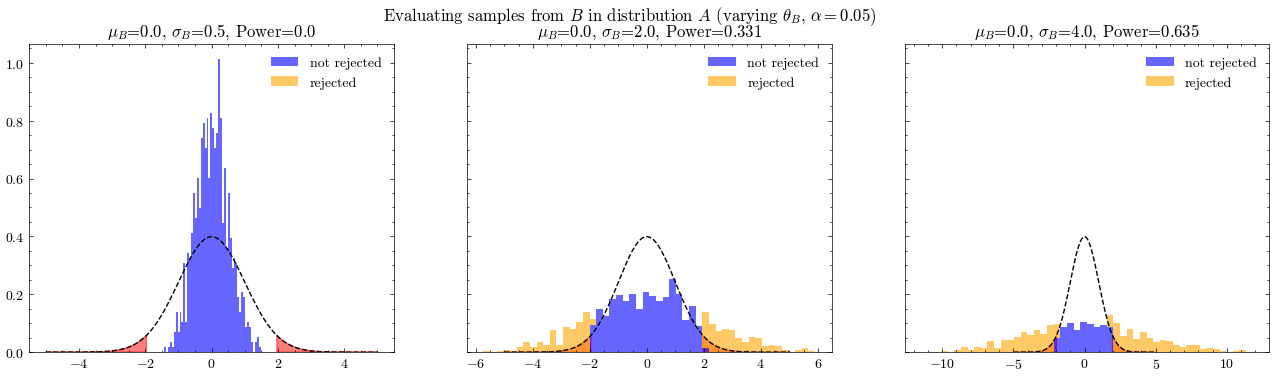

In [4]:
plot_gaussian_b_in_a(mu_b=[0.0, 0.0, 0.0], sigma_b=[0.5, 2.0, 4.0], alpha=0.05)

As you might have expected, we cannot detect differences between the distributions if $B$ is "enclosed" by $A$ (left plot). However, the FPR is still bounded, because we do not falsely claim samples from $A$ to be from $B$. The Power of the test increases proportionally to both $|\mu_B - \mu_A|$ and to $\sigma_B-\sigma_A$ (but not necessarily jointly, as you can see on the right side of the next plot compared to its left neighbor).  

To evaluate the procedure as a whole, we will use data containing samples from $A$ and $B$, with $A=T$ being the true model. The task is to assign each observation a $p$-value, and declare them as OOD, if $\hat{p}(x)<=\alpha$, and In-Distribution (ID) else. We draw $n=1000$ samples from both $A\sim \mathcal{N}(0, 1)$ and $B\sim \mathcal{N}(\mu_B, \sigma_B), (\mu_B, \sigma_B) \in \{(0, 3), (3, 1), (3, 3)\}$. This results in dataset $X$ of size $2000$. For each $x\in X$, we will evaluate $\hat{p}_A(x)$ and declare $x$ OOD if $\hat{p}_A(x)\leq \alpha = 0.05$. We compute the confusion matrix w.r.t. the original distribution and the OOD decisions. 

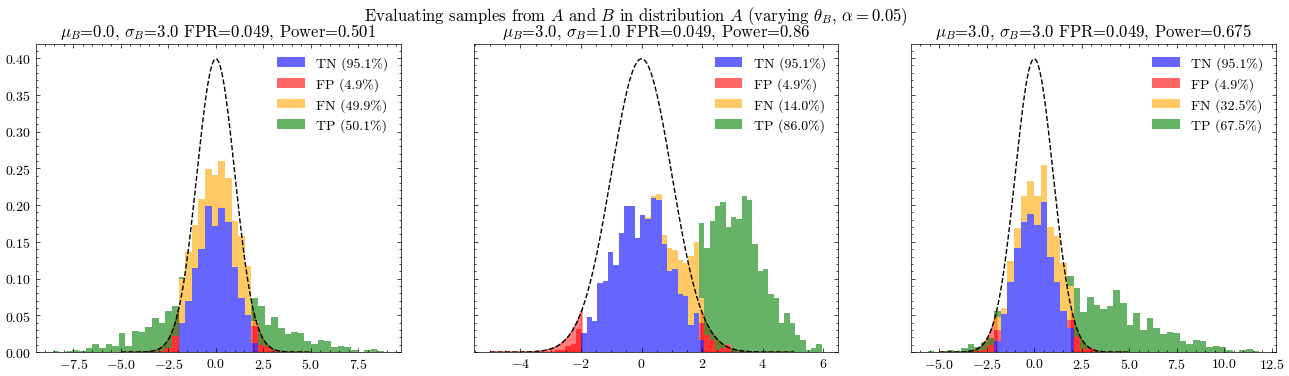

In [5]:
def plot_gaussian_mixed_in_a(mu_b, sigma_b, alpha, mu_a=0.0, sigma_a=1.0, n_samples=1000, seed=47):
    assert isinstance(mu_b, list) and isinstance(sigma_b, list) and len(mu_b) == len(sigma_b)
    gaussian_a = norm(loc=mu_a, scale=sigma_a)
    gaussian_b_collection = [norm(loc=m, scale=s) for (m, s) in zip(mu_b, sigma_b)]
    rejection_threshold = mu_a+1.96*sigma_a

    k = len(gaussian_b_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-5.0, stop=5.0, num=1000)

    for gaussian_b, ax in zip(gaussian_b_collection, axes):
        density_a = gaussian_a.pdf(x=x)
        ax.plot(x, density_a, color="black", linestyle="--")
        ax.fill_between(x=x, y1=np.zeros_like(x), y2=density_a, where=np.abs(x)>=rejection_threshold, alpha=0.5, color="red")
        # ax.axvline(-rejection_threshold, color="red", linestyle="--")
        # ax.axvline(rejection_threshold, color="red", linestyle="--")

        samples_a = gaussian_a.rvs(size=n_samples, random_state=seed)
        labels_a = np.zeros_like(samples_a)
        samples_b = gaussian_b.rvs(size=n_samples, random_state=seed)
        labels_b = np.ones_like(samples_b)
        samples = np.concat((samples_a, samples_b), axis=0)
        labels = np.concat((labels_a, labels_b), axis=0)
        pvalues = twosided_test_single_univariate_symmetric(distribution=gaussian_a, data=samples)
        out_of_distribution_mask = pvalues <= alpha
        
        tn, fp, fn, tp = confusion_matrix(y_true=labels, y_pred=out_of_distribution_mask.astype(int)).ravel().tolist()
        tpr = tp / (tp + fn) if (tp+fn) != 0 else 0.0
        fpr = fp / (fp + tn) if (fp+tn) != 0 else 0.0

        decisions = {
            "TN": samples_a[~out_of_distribution_mask[labels==0]], 
            "FP": samples_a[out_of_distribution_mask[labels==0]],
            "FN": samples_b[~out_of_distribution_mask[labels==1]],
            "TP": samples_b[out_of_distribution_mask[labels==1]],
        }
        colors = {
            "TN": "blue", 
            "FP": "red", 
            "FN": "orange", 
            "TP": "green"
        }
        labels_plot = {
            "TN": f"TN ({(1.0-fpr)*100:.1f}%)",
            "FP": f"FP ({fpr*100:.1f}%)",
            "FN": f"FN ({(1.0-tpr)*100:.1f}%)",
            "TP": f"TP ({tpr*100:.1f}%)",
        }

        ax.hist(x=decisions.values(), bins=50, color=colors.values(), stacked=True, alpha=0.6, density=True, label=labels_plot.values())

        ax.set_title(rf"$\mu_B$={gaussian_b.mean()}, $\sigma_B$={gaussian_b.std()} FPR={fpr}, Power={tpr}")
        ax.legend()

    fig.suptitle(f"Evaluating samples from $A$ and $B$ in distribution $A$ (varying $\\theta_B$, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

plot_gaussian_mixed_in_a(mu_b=[0.0, 3.0, 3.0], sigma_b=[3.0, 1.0, 3.0], alpha=0.05)

We can see that the FPR remains bounded $\alpha$, as guaranteed by the testing procedure. The power behaves antiproportional to the "closeness" of the two distributions (TODO: quantify this using e.g. symmetrized KL divergence?). 

So far, you may have seen nothing new. Let's get to the interesting part:  
**What does it mean if the FPR of our procedure exceeds $\alpha$?**  
To be more specific, what does $x \sim T: \text{FPR}_{A(x)}>\alpha$ imply for $A$?  

Spoiler alert: This means that $A\neq T$! This follows by inversion of $x \sim T: A=T \Rightarrow \text{FPR}_{A(x)}\leq\alpha$ (given that $T(x)$ produces valid $p$-values). Now we have a building block of giving an upper bound on the quality of the circuit; e.g. if the model is wrong w.r.t. data $X$. This can happen when our estimator (or our learning procedure) produces a false model, e.g. by being biased or by making wrong assumptions about the data. Let's plot different biases to the estimated distribution $A$.



<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_3848/3710516656.py:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  fig.suptitle(f"Evaluating samples $x\sim T$ in wrongly estimated $A$ (varying $\\theta_A$, $\\alpha={alpha}$)")


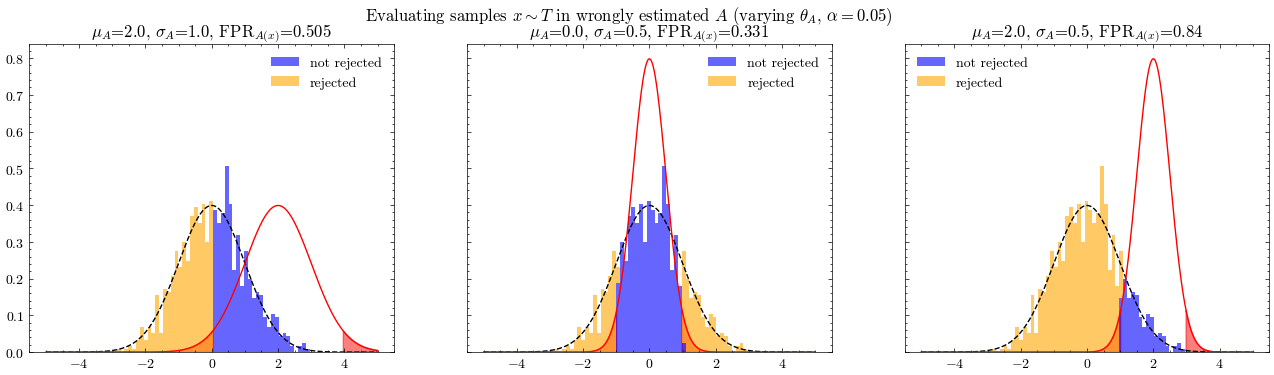

In [6]:
def plot_gaussian_a_unequal_t(mu_a, sigma_a, alpha, mu_t=0.0, sigma_t=1.0, n_samples=1000, seed=47):
    assert isinstance(mu_a, list) and isinstance(sigma_a, list) and len(mu_a) == len(sigma_a)
    gaussian_t = norm(loc=mu_t, scale=sigma_t)

    gaussian_a_collection = [norm(loc=m, scale=s) for (m, s) in zip(mu_a, sigma_a)]

    k = len(gaussian_a_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-5.0, stop=5.0, num=1000)

    for gaussian_a, ax in zip(gaussian_a_collection, axes):
        rejection_threshold = [gaussian_a.mean() - 1.96*gaussian_a.std(), gaussian_a.mean()+1.96*gaussian_a.std()]
        gaussian_density_t = gaussian_t.pdf(x=x)
        gaussian_density_a = gaussian_a.pdf(x=x)
        ax.plot(x, gaussian_density_t, color="black", linestyle="--")
        ax.plot(x, gaussian_density_a, color="red", linestyle="-")
        ax.fill_between(x=x, y1=np.zeros_like(x), y2=gaussian_density_a, where=[not rejection_threshold[0]<=_<=rejection_threshold[1] for _ in x], alpha=0.5, color="red")

        gaussian_samples = gaussian_t.rvs(size=n_samples, random_state=seed)
        pvalues = twosided_test_single_univariate_symmetric(distribution=gaussian_a, data=gaussian_samples)
        out_of_distribution_mask = pvalues <= alpha
        ax.hist(x=[gaussian_samples[~out_of_distribution_mask], gaussian_samples[out_of_distribution_mask]], bins=50, color=["blue", "orange"], stacked=True, alpha=0.6, density=True, label=["not rejected", "rejected"])

        false_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / n_samples
        fpr_tex_string = "$\\text{FPR}_{A(x)}$" 
        ax.set_title(rf"$\mu_A$={gaussian_a.mean()}, $\sigma_A$={gaussian_a.std()}, {fpr_tex_string}={false_positive_rate}")

        ax.legend()

    fig.suptitle(f"Evaluating samples $x\sim T$ in wrongly estimated $A$ (varying $\\theta_A$, $\\alpha={alpha}$)")
    plt.show()
    plt.close("all")

plot_gaussian_a_unequal_t(mu_a=[2.0, 0.0, 2.0], sigma_a=[1.0, 0.5, 0.5], alpha=0.05)

TODO results and discussion of plot

Note: We can use 1.0-max(0, FPR - alpha) as model quality. Interpret this as: "We know that the model is at least max(0, FPR-alpha) wrong" 
ML extension: Can we learn alpha w.r.t. this loss? Does this learn the e.g. 5% threshold of the data (no assumptions about structure of distribution on both sides of this threshold)? does this increase the power? Naive approach: Just correct alpha w.r.t. FPR; e.g. alpha_corrected = alpha * (alpha/FPR)

#### Testing in Mixture Models <a class="anchor" id="testing-mixtures"></a>

In a mixture model, we have two possible strategies to compute its $p$-value:
1. Compute the CDF (or a rejection region similar to the Confidence Interval) of the mixture and compute $p$-values of observations in this function.
2. Compute $p$-values of each mixture component and aggregate them into a $p$-value of the mixture.

The first approach will only work when we have access to the CDFs (or moments) of each component. If the children are e.g. Gaussian, this is the case, and we are good to go. However, we want to build PCs. Then, we encounter problems: 1. Their CDF might be available, but it is not clear how to choose a $p$-value from a multivariate CDF. 2. The moments might be available, but its still not clear how to assess an observation versus the vectors of moments of a multivariate distribution.

To avoid these, we will cast the problem of computing a multivariate $p$-value as a multiple testing problem. By exploiting the structure of learned circuits, we can use the univariate distributions encoded by leafs to compute univariate $p$-values, and then use appropriate functions to merge them into valid (& possibly precise) $p$-values.

Vovk & Wang's paper "Combining $p$-values via Averaging" shows us that a corrected version of the weighted arithmetic mean is a valid merging function, i.e. transforms a list of valid $p$-values into a valid $p$-value. They provide the formula (Proposition 5w):

$$\hat{p}_{X}(x) = \min(2, \frac{1}{\max \{w_i\}_{i=1}^k }) \sum_{i=1}^k w_i \hat{p}_{X_i}(x)$$

where $w_i$ are the mixture weights of our mixture model with $k$ components, each encoding $p_{X_i}$. This formula ensure that regardless the distribution of the weights, the result will be a valid $p$-value. Moreover, if one component dominates the mixture model, its $p$-values will also contribute more to the multivariate $p$-value (Note the convergence $\lim_{w_i\rightarrow 1} \hat{p}_{X} = \hat{p}_{X_i}$).


In [7]:
class MixtureModel:
    def __init__(self, mixture_components, mixture_weights):
        assert len(mixture_components) == len(mixture_weights)
        assert np.isclose(np.sum(mixture_weights), 1.0)
        if not isinstance(mixture_weights, np.ndarray):
            mixture_weights = np.array(mixture_weights)
        self.mixture_components = mixture_components
        self.mixture_weights = mixture_weights.reshape(-1, 1)

    def pdf(self, x):
        pdfs_children = []
        for child in self.mixture_components:
            pdf_child = child.pdf(x).reshape(-1, 1)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        pdf_mixture = pdfs_children @ self.mixture_weights
        return pdf_mixture.squeeze()
    
    def sample(self, n_samples, seed=47):
        samples_children = []
        for child in self.mixture_components:
            samples_child = child.rvs(n_samples, random_state=seed).reshape(-1, 1)
            samples_children.append(samples_child)
        samples_children = np.concat(samples_children, axis=1)

        cluster_selector = multinomial.rvs(n=1, p=self.mixture_weights.squeeze(), size=n_samples, random_state=seed).reshape(-1, len(self.mixture_weights))
        cluster_selector = np.argmax(cluster_selector, axis=1, keepdims=True)

        samples_mixture = np.take_along_axis(samples_children, cluster_selector, axis=1).squeeze()
        return samples_mixture
    
    def rvs(self, size, random_state=47):
        return self.sample(n_samples=size, seed=random_state)
    
    def mean(self):
        means_children = np.array([child.mean() for child in self.mixture_components]).reshape(1, -1)
        mixture_mean = (means_children @ self.mixture_weights).squeeze()
        return mixture_mean
    
    def var(self):
        means_children = np.array([child.mean() for child in self.mixture_components]).reshape(-1, 1)
        var_children = np.array([child.var() for child in self.mixture_components]).reshape(-1, 1)

        mixture_variance_term1 = self.mixture_weights.T @ (np.pow(means_children, 2) + var_children)
        mixture_variance_term2 = np.pow(self.mixture_weights.T @ means_children, 2)
        mixture_variance = (mixture_variance_term1 - mixture_variance_term2).squeeze()
        
        return mixture_variance
    
    def std(self):
        mixture_variance = self.var()
        mixture_stdev = np.sqrt(mixture_variance)
        return mixture_stdev
    
    def pvalues(self, x):
        pvalues_children = []
        for child in self.mixture_components:
            pvalues_child = twosided_test_single_univariate_symmetric(child, x).reshape(-1, 1)
            pvalues_children.append(pvalues_child)
        pvalues_children = np.concat(pvalues_children, axis=1)

        correction_term = min(2.0, 1 / np.max(self.mixture_weights))
        # correction_term = max(2.0, 1 / np.max(self.mixture_weights))
        pvalue_mixture = correction_term * (pvalues_children @ self.mixture_weights)

        return pvalue_mixture.squeeze()

Mixture model stats: 
- Mean: 1.33
- Variance: 4.97
- 'Confidence Interval': [-3.04, 5.70] 


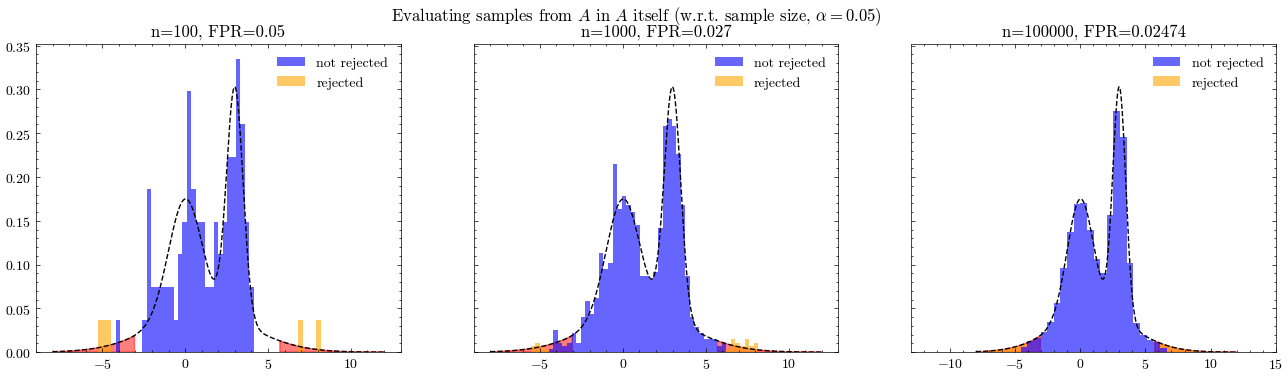

In [8]:
def plot_mixture_model(distribution, alpha, n_samples, seed=47):
    rejection_threshold = [distribution.mean() - 1.96*distribution.std(), distribution.mean() + 1.96*distribution.std()]

    k = len(n_samples)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-8.0, stop=12.0, num=1000)

    for sample_size, ax in zip(n_samples, axes):
        gaussian_density = distribution.pdf(x=x)
        ax.plot(x, gaussian_density, color="black", linestyle="--")
        ax.fill_between(x=x, y1=np.zeros_like(x), y2=gaussian_density, where=[not rejection_threshold[0]<=_<=rejection_threshold[1] for _ in x], alpha=0.5, color="red")

        gaussian_samples = distribution.rvs(size=sample_size, random_state=seed)
        pvalues = distribution.pvalues(gaussian_samples)
        out_of_distribution_mask = pvalues <= alpha
        # out_of_distribution_mask_CI = np.array([not rejection_threshold[0]<=_<=rejection_threshold[1] for _ in gaussian_samples])
        ax.hist(x=[gaussian_samples[~out_of_distribution_mask], gaussian_samples[out_of_distribution_mask]], bins=50, color=["blue", "orange"], stacked=True, alpha=0.6, density=True, label=["not rejected", "rejected"])

        false_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / sample_size
        # false_positive_rate_CI = np.sum(out_of_distribution_mask_CI.astype(int)) / sample_size
        ax.set_title(rf"n={sample_size}, FPR={false_positive_rate}")

        ax.legend()

    fig.suptitle(f"Evaluating samples from $A$ in $A$ itself (w.r.t. sample size, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

mixture_a = MixtureModel([norm(loc=0.0, scale=1.0), norm(loc=1.0, scale=3.0), norm(loc=3.0, scale=0.5)], mixture_weights=[1/3, 1/3, 1/3])

mean = mixture_a.mean()
var = mixture_a.var()
std = mixture_a.std()
print("Mixture model stats: ")
print(f"- Mean: {mean:.2f}")
print(f"- Variance: {var:.2f}")
print(f"- 'Confidence Interval': [{mean - 1.96 * std:.2f}, {mean + 1.96 * std:.2f}] ")

plot_mixture_model(mixture_a, alpha=0.05, n_samples=[100, 1000, 100000], seed=47)

Memo: The FPR w.r.t. the moments (declaring $x$ as OOD if it is outside the "Confidence Interval") leads to results $\geq 5\%$. This either means that 1. My computation of the variance / standard deviation is wrong, e.g. forgot a term, or 2. The "CI" method does not work for Mixture Models.

Let's repeat that for a mixture whose components are "farther away":

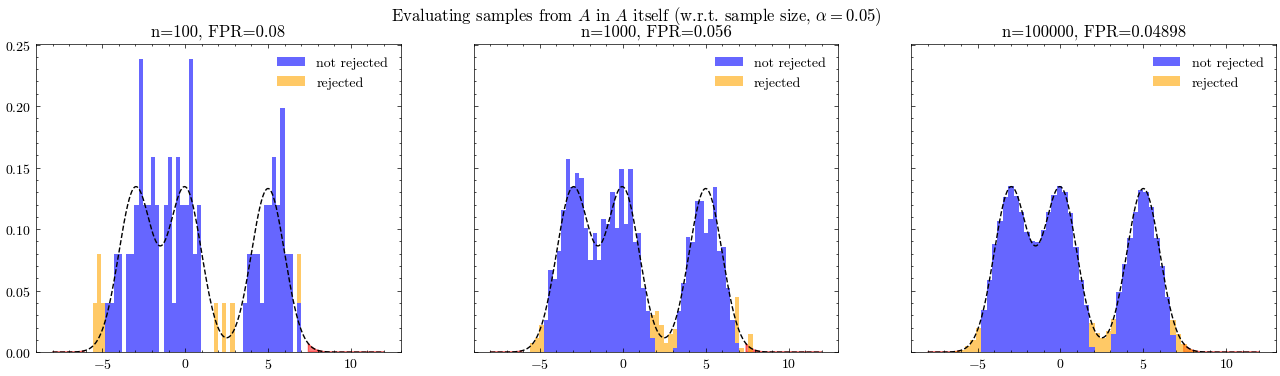

In [9]:
mixture_distributed = MixtureModel(mixture_components=[norm(loc=-3, scale=1.0), norm(loc=0, scale=1.0), norm(5, scale=1.0)], mixture_weights=[1/3, 1/3, 1/3])
plot_mixture_model(mixture_distributed, alpha=0.05, n_samples=[100, 1000, 100000])

We can see that again, for the larger sample sizes, the FPR becomes closer to $\alpha$. Moreover, the combined $p$-values also leads to rejections "between" two distributions where the density is respectively low.  
Note: We encounter one problem here: We are evaluating one observation in multiple models, and most (if not all) models are the wrong one for the given observation. This may lead to FPR $> \alpha$. Two options now: 1. We ignore this. Then the result of the SC is not a $p$-value, but a score assessing the relationship of the observation to the circuit. 2. We do a density-pass first and only evaluate the $p$-value of the sub-circuit which is closest to the observation, e.g. the induced tree // induced path of the observation w.r.t. its density in the model. This would "remove" the Arithmetic Mean at Sum Nodes, we would only use the Harmonic Mean at Product Nodes. This should then imply validity of the test and guarantee FPR $\leq \alpha$. 3. We correct the correction term of Vovk&Wang, i.e. we don't bound the correction term at 2, but just compute $\hat{p}_{X}(x) = \frac{1}{\max \{w_i\}_{i=1}^k } \sum_{i=1}^k w_i \hat{p}_{X_i}(x)$ (but this might not work, need to think about this).


The 2nd method, first selecting the "most probable induced tree" by only computing the $p$-value of one child per Sum Node // Mixture based on which child returned the highest weighted density for one particular observation, is implemented next.

Use corrected Arithmetic Mean at Sum Nodes (average over all clusters)


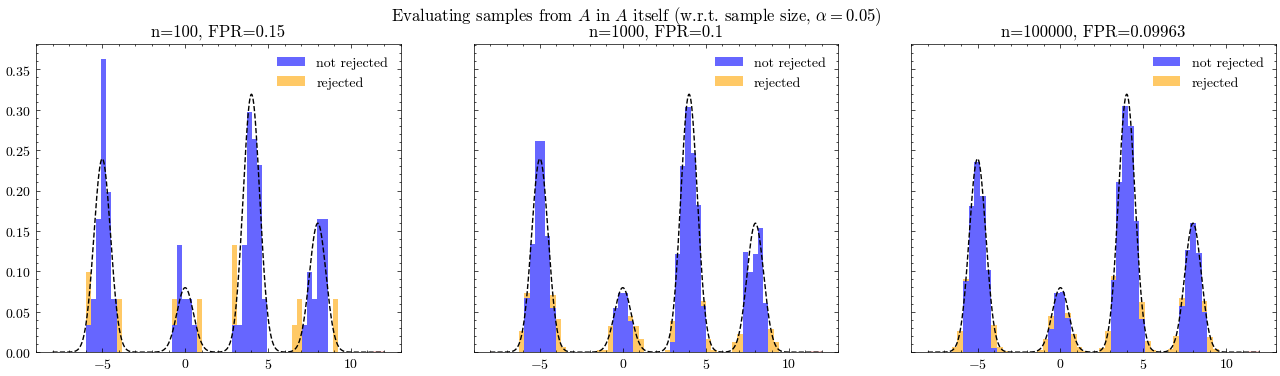

Select child with highest likelihood at Sum Nodes (effectively using only one cluster per RV)


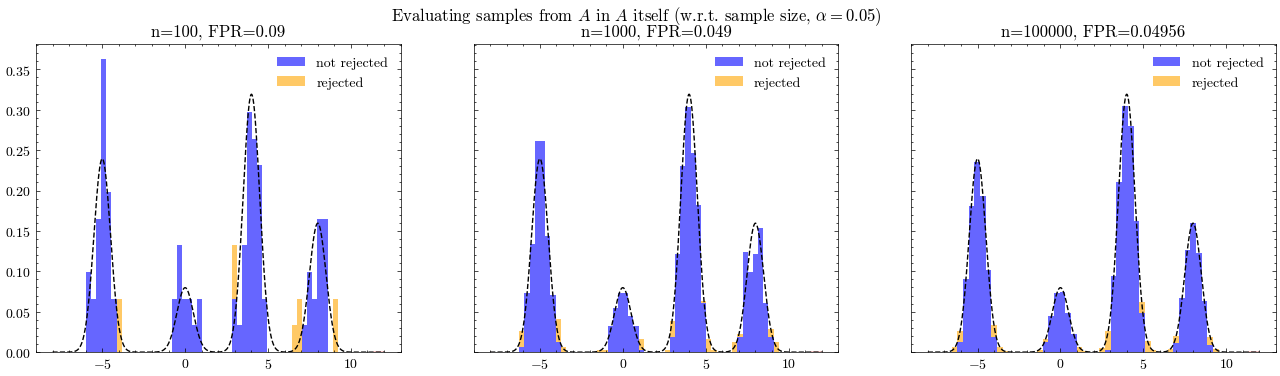

In [10]:
class MixtureModelWithSelection(MixtureModel):
    def _most_likely_component_index(self, x):
        pdfs_children = []
        for child in self.mixture_components:
            pdf_child = child.pdf(x).reshape(-1, 1)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        
        weighted_pdfs_children = np.array(self.mixture_weights).T * pdfs_children
        most_likely_components_indexes = np.argmax(weighted_pdfs_children, axis=1, keepdims=True)

        return most_likely_components_indexes
    
    def pvalues(self, x):
        pvalues_children = []
        for child in self.mixture_components:
            pvalues_child = twosided_test_single_univariate_symmetric(child, x).reshape(-1, 1)
            pvalues_children.append(pvalues_child)
        pvalues_children = np.concat(pvalues_children, axis=1)

        most_likely_component_index = self._most_likely_component_index(x)
        pvalue_mixture = np.take_along_axis(pvalues_children, most_likely_component_index, axis=1)

        return pvalue_mixture.squeeze()

# aggregating at miture
print("Use corrected Arithmetic Mean at Sum Nodes (average over all clusters)")
mixture_distributed = MixtureModel(mixture_components=[norm(loc=-5, scale=0.5), norm(loc=0, scale=0.5), norm(loc=4, scale=0.5), norm(loc=8, scale=0.5)], mixture_weights=[0.3, 0.1, 0.4, 0.2])
plot_mixture_model(mixture_distributed, alpha=0.05, n_samples=[100, 1000, 100000])
# selecting induced tree with highest likelihood
print("Select child with highest likelihood at Sum Nodes (effectively using only one cluster per RV)")
mixture_distributed_with_selection = MixtureModelWithSelection(mixture_components=[norm(loc=-5, scale=0.5), norm(loc=0, scale=0.5), norm(loc=4, scale=0.5), norm(loc=8, scale=0.5)], mixture_weights=[0.3, 0.1, 0.4, 0.2])
plot_mixture_model(mixture_distributed_with_selection, alpha=0.05, n_samples=[100, 1000, 100000])

The first plot shows what happens when we combine the $p$-values of all components. The farther away the components' distributions are from each other, the more "wrong" all except one of them are w.r.t. one particular observation. This leads to an overall to often rejection and a high FPR for the mixture model.  
The second plot shows that if we test within the induced trees, and do not combine (hence also do not correct) the $p$-values, the FPR is bounded again by $\alpha$.

Now, let's ses what happens when the samples are generated from other mixtures where one of the components is different.

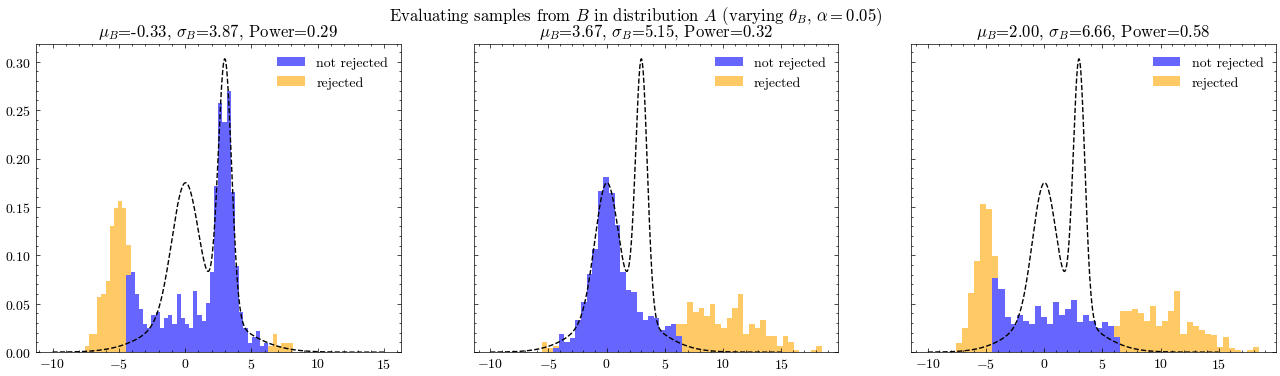

In [11]:
def plot_mixture_b_in_a(mixture_a, mixture_b_collection, alpha, n_samples=1000, seed=47):

    k = len(mixture_b_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)
    x = np.linspace(start=-10.0, stop=15.0, num=1000)

    for gaussian_b, ax in zip(mixture_b_collection, axes):
        density_a = mixture_a.pdf(x=x)
        ax.plot(x, density_a, color="black", linestyle="--")

        samples_b = gaussian_b.rvs(size=n_samples, random_state=seed)
        pvalues = mixture_a.pvalues(samples_b)
        out_of_distribution_mask = pvalues <= alpha
        ax.hist(x=[samples_b[~out_of_distribution_mask], samples_b[out_of_distribution_mask]], bins=50, color=["blue", "orange"], stacked=True, alpha=0.6, density=True, label=["not rejected", "rejected"])

        true_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / n_samples
        ax.set_title(rf"$\mu_B$={gaussian_b.mean():.2f}, $\sigma_B$={gaussian_b.std():.2f}, Power={true_positive_rate:.2f}")

        ax.legend()

    fig.suptitle(f"Evaluating samples from $B$ in distribution $A$ (varying $\\theta_B$, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

mixture_a =  MixtureModel([norm(loc=0.0, scale=1.0), norm(loc=1.0, scale=3.0), norm(loc=3.0, scale=0.5)], mixture_weights=[1/3, 1/3, 1/3])
mixture_b1 = MixtureModel([norm(loc=-5.0, scale=1.0), norm(loc=1.0, scale=3.0), norm(loc=3.0, scale=0.5)], mixture_weights=[1/3, 1/3, 1/3])
mixture_b2 = MixtureModel([norm(loc=0.0, scale=1.0), norm(loc=1.0, scale=3.0), norm(loc=10.0, scale=3.0)], mixture_weights=[1/3, 1/3, 1/3])
mixture_b3 = MixtureModel([norm(loc=-5.0, scale=1.0), norm(loc=1.0, scale=3.0), norm(loc=10.0, scale=3.0)], mixture_weights=[1/3, 1/3, 1/3])

plot_mixture_b_in_a(mixture_a=mixture_a, mixture_b_collection=[mixture_b1, mixture_b2, mixture_b3], alpha=0.05)

Let's discuss the results:
1. The power is rather low. But this is not surprising, as the Power here represents the portion of observations that are declared as OOD, which is not possible in regions where the two distributions have significant overlap.
2. We can see which observations the test deems to be "In-Distribution" and "Out-Of-Distribution". The observed rejection regions // rejection thresholds align with what we (or at least I) would expect from a procedure assigning scores to individual observations. We can see this as a confirmation of the procedure working (in the case of a Mixture Model //  Sum Node). So even if we might not be able to distinguish the distributions, we can detect instances that are not from our estimated one. 

We can skip the evaluation of a mixed dataset within the mixture model, as it is now clear which observations would be deemed OOD and which not.  

#### Testing in Fully Factorized Models <a class="anchor" id="testing-factorized"></a>

What happens if we test two random variables separately and then combine their $p$-values into a $p$-value of the joint distribution? Before combining this idea with mixture models (resulting in PCs), let's investigate the behavior of merging $p$-values of statistically independent RVs.

In [12]:
class FactorizedModel:
    def __init__(self, mixture_components):
        self.mixture_components = mixture_components

    def pdf(self, x):
        pdfs_children = []
        for scope, child in enumerate(self.mixture_components):
            x_child = x[:, scope]
            pdf_child = child.pdf(x_child).reshape(-1, 1)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        pdf_mixture = np.prod(pdfs_children, axis=1)
        return pdf_mixture.squeeze()
    
    def sample(self, n_samples, seed=47):
        samples_children = []
        for scope, child in enumerate(self.mixture_components):
            seed_child = seed+scope
            samples_child = child.rvs(n_samples, random_state=seed_child).reshape(-1, 1)
            samples_children.append(samples_child)
        samples_mixture = np.concat(samples_children, axis=1)
        return samples_mixture
    
    def rvs(self, size, random_state=47):
        return self.sample(n_samples=size, seed=random_state)
    
    def mean(self):
        means_children = np.array([child.mean() for child in self.mixture_components])
        return means_children.squeeze()
    
    def var(self):
        var_children = np.array([child.var() for child in self.mixture_components])
        return var_children.squeeze()
    
    def std(self):
        mixture_variance = self.var()
        mixture_stdev = np.sqrt(mixture_variance)
        return mixture_stdev
    
    def pvalues(self, x, *args):
        pvalues_children = []
        for scope, child in enumerate(self.mixture_components):
            x_child = x[:, scope]
            pvalues_child = twosided_test_single_univariate_symmetric(child, x_child).reshape(-1, 1)
            pvalues_children.append(pvalues_child)
        pvalues_children = np.concat(pvalues_children, axis=1)

        K = len(self.mixture_components)
        correction_term = np.e * np.log(K)
        pvalue_mixture = correction_term * hmean(pvalues_children, axis=1)

        return pvalue_mixture.squeeze()

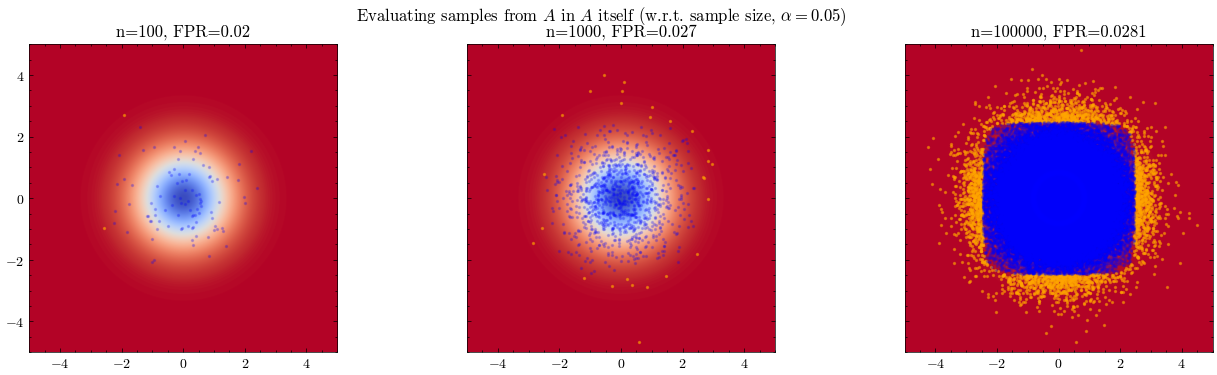

In [13]:
def plot_2d_A_in_A(distribution, alpha, n_samples, select_at_sum_nodes=False, grid_limit=5.0, n_grid=1000, seed=47):

    extent = [-grid_limit, grid_limit, -grid_limit, grid_limit]
    linspace = np.linspace(-grid_limit, grid_limit, n_grid)
    X, Y = np.meshgrid(linspace, -linspace, indexing="xy")
    grid = np.dstack((X, Y)).reshape(n_grid**2, 2)

    # pvalue_grid = factorized_model.pvalues(grid).reshape(n_grid, n_grid)
    density_grid = distribution.pdf(grid).reshape(n_grid, n_grid)

    k = len(n_samples)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)

    for sample_size, ax in zip(n_samples, axes):
        # ax.imshow(pvalue_grid, cmap="coolwarm_r", extent=extent, vmin=0.0, vmax=1.0, origin="upper")
        ax.imshow(density_grid, cmap="coolwarm_r", extent=extent)

        gaussian_samples = distribution.sample(n_samples=sample_size, seed=seed)
        pvalues = distribution.pvalues(gaussian_samples, "two-sided", select_at_sum_nodes)
        out_of_distribution_mask = pvalues <= alpha
        ax.scatter(x=gaussian_samples[:, 0][out_of_distribution_mask], y=gaussian_samples[:, 1][out_of_distribution_mask], color=["orange"], alpha=0.5, label="rejected", s=2)
        ax.scatter(x=gaussian_samples[:, 0][~out_of_distribution_mask], y=gaussian_samples[:, 1][~out_of_distribution_mask], color=["blue"], alpha=0.2, label="not rejected", s=2)

        false_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / sample_size
        ax.set_title(rf"n={sample_size}, FPR={false_positive_rate}")

        # ax.legend()

    fig.suptitle(f"Evaluating samples from $A$ in $A$ itself (w.r.t. sample size, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

ff_model = FactorizedModel(mixture_components=[norm(loc=0.0, scale=1.0), norm(loc=0.0, scale=1.0)])
plot_2d_A_in_A(ff_model, alpha=0.05, n_samples=[100, 1000, 100000])


Now we could also do experiments similar to the univariate case, but the results should now be easy to infer, e.g. moving the distribution or the samples around. We get the probabilistic guarantee on the FPR due to the Harmonic Mean being a $p$-value merging function (but only valid, not precise in this case; compare Vovk&Wang2020), and obiously observations from another distribution will have a higher chance of receiving a low $p$-value the farther away that distribution is.

Note: We could also implement Bonferroni or Tippett instead of Harmonic Mean (show proof?)

#### Multivariate Testing with PCs <a class="anchor" id="testing-pcs"></a>

Finally, let us combine what we have seen so far.

Definition PC, SC, Proof that SC is a $p$-variable, etc.



In [ ]:
class MembershipCircuit:
    def __init__(self, scope):
        self.scope = scope
    def pdf(self, x):
        raise NotImplementedError
    def sample(self, n_samples):
        raise NotImplementedError
    def pvalues(self, x, side="two-sided", select_most_probable_cluster=False):
        raise NotImplementedError
    def mean(self):
        raise NotImplementedError
    def var(self):
        raise NotImplementedError
    def std(self):
        raise NotImplementedError
    
class SumNode(MembershipCircuit):
    def __init__(self, scope, children, weights):
        assert len(children) == len(weights)
        assert np.isclose(np.sum(weights), 1.0)
        if not isinstance(weights, np.ndarray):
            weights = np.array(weights)
        self.children = children
        self.weights = weights.reshape(-1, 1)
        super().__init__(scope)

    def pdf(self, x):
        pdfs_children = []
        for child in self.children:
            pdf_child = child.pdf(x)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        pdf_mixture = pdfs_children @ self.weights
        return pdf_mixture

    def sample(self, n_samples, seed=47):
        samples_children = []
        for child in self.children:
            samples_child = child.sample(n_samples, seed=seed)
            samples_children.append(samples_child)
        # samples_children = np.concat(samples_children, axis=1)
        sample_shape = samples_children[0].shape
        samples_children = np.dstack(samples_children)

        cluster_selector = multinomial.rvs(n=1, p=self.weights.squeeze(), size=n_samples, random_state=seed).reshape(-1, 1, len(self.weights))
        cluster_selector = np.argmax(cluster_selector, axis=-1, keepdims=True)

        samples_mixture = np.take_along_axis(samples_children, cluster_selector, axis=-1)
        return samples_mixture.reshape(*sample_shape)
    
    def pvalues(self, x, side="two-sided", select_most_probable_cluster=False):
        pvalues_children = []
        for child in self.children:
            pvalues_child = child.pvalues(x, side, select_most_probable_cluster).reshape(-1, 1)
            pvalues_children.append(pvalues_child)
        pvalues_children = np.concat(pvalues_children, axis=1)

        if select_most_probable_cluster:
            most_likely_component_index = self._most_likely_component_index(x)
            pvalue_mixture = np.take_along_axis(pvalues_children, most_likely_component_index, axis=1)
        else:
            correction_term = min(2.0, 1 / np.max(self.weights))
            pvalue_mixture = correction_term * (pvalues_children @ self.weights)

        return pvalue_mixture.squeeze()
    
    def _most_likely_component_index(self, x):
        pdfs_children = []
        for child in self.children:
            pdf_child = child.pdf(x).reshape(-1, 1)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        
        weighted_pdfs_children = np.array(self.weights).T * pdfs_children
        most_likely_component_indexes = np.argmax(weighted_pdfs_children, axis=1, keepdims=True)

        return most_likely_component_indexes
    
    def mean(self):
        means_children = np.concat([child.mean() for child in self.children], axis=0)
        mixture_mean = self.weights.T @ means_children
        return mixture_mean
    
    def var(self):
        means_children = np.concat([child.mean() for child in self.children], axis=0)
        var_children = np.concat([child.var() for child in self.children], axis=0)

        mixture_variance_term1 = self.weights.T @ (np.pow(means_children, 2) + var_children)
        mixture_variance_term2 = np.pow(self.weights.T @ means_children, 2)
        mixture_variance = mixture_variance_term1 - mixture_variance_term2
        
        return mixture_variance
    
    def std(self):
        mixture_variance = self.var()
        mixture_stdev = np.sqrt(mixture_variance)
        return mixture_stdev
    

class ProductNode(MembershipCircuit):
    def __init__(self, scope, children):
        self.children = children
        super().__init__(scope)

    def pdf(self, x):
        pdfs_children = []
        for i, child in enumerate(self.children):
            pdf_child = child.pdf(x).reshape(-1, 1)
            pdfs_children.append(pdf_child)
        pdfs_children = np.concat(pdfs_children, axis=1)
        pdf_mixture = np.prod(pdfs_children, axis=1, keepdims=True)
        return pdf_mixture
    
    def sample(self, n_samples, seed=47):
        samples_children = []
        for i, child in enumerate(self.children):
            seed_child = seed+self.scope[i]
            samples_child = child.sample(n_samples, seed=seed_child)
            samples_children.append(samples_child)
        samples_mixture = np.concat(samples_children, axis=1)
        return samples_mixture
    
    def pvalues(self, x, side="two-sided", select_most_probable_cluster=False):
        pvalues_children = []
        for child in self.children:
            pvalues_child = child.pvalues(x, side, select_most_probable_cluster).reshape(-1, 1)
            pvalues_children.append(pvalues_child)
        pvalues_children = np.concat(pvalues_children, axis=1)

        K = len(self.children)
        correction_factor = self._compute_adaptive_correction_factor(K)
        pvalue_mixture = correction_factor * hmean(pvalues_children, axis=1)

        return pvalue_mixture.squeeze()
    
    @cache
    def _compute_adaptive_correction_factor(self, K):
        def compute_y(y, K):
            return y**2 - K * ((y + 1) * np.log(y + 1) - y)
        def compute_akh(K):
            y_k = root_scalar(compute_y, args=(K,), bracket=[1e-6, 1e6], method="brentq").root
            akh = (y_k+K)**2 / ((y_k+1)*K)
            return akh
        
        if K > 2:
            akh = compute_akh(K)
        else:
            akh = np.e
        correction_factor = akh * np.log(K)
        return correction_factor
    
    def mean(self):
        means_children = np.concat([child.mean() for child in self.children], axis=1)
        return means_children
    
    def var(self):
        variance_children = np.concat([child.var() for child in self.children], axis=1)
        return variance_children
    
    def std(self):
        variance = self.var()
        stdev = np.sqrt(variance)
        return stdev

    
class LeafNode(MembershipCircuit):
    def __init__(self, scope):
        super().__init__(scope)


class GaussianLeaf(LeafNode):
    def __init__(self, scope, mu, sigma):
        self.mu = mu
        self.sigma = sigma
        super().__init__(scope)

    def pdf(self, x):
        x_leaf = x[:, self.scope[0]]
        densities = norm.pdf(x=x_leaf, loc=self.mu, scale=self.sigma).reshape(-1, 1)
        return densities
    
    def sample(self, n_samples, seed):
        rs = seed + self.scope[0]
        samples = norm.rvs(size=n_samples, loc=self.mu, scale=self.sigma, random_state=rs)
        return samples.reshape(-1, 1)
    
    def pvalues(self, x, side="two-sided", select_most_probable_cluster=False):
        x_leaf = x[:, self.scope[0]]
        dist = norm.cdf(x=x_leaf, loc=self.mu, scale=self.sigma)
        if side == "two-sided":
            pvalue = 2 * np.minimum(dist, 1.0 - dist)
        elif side == "left-sided":
            pvalue = dist
        elif side == "right-sided":
            pvalue = 1.0 - dist
        return pvalue.squeeze() 
    
    def mean(self):
        return np.array(self.mu).reshape(1,1)
    
    def var(self):
        variance = self.sigma ** 2
        return np.array(variance).reshape(1,1)
    
    def std(self):
        return np.array(self.sigma).reshape(1,1)

In [15]:
# define two possible circuits of depth 2 over 2 random variables 
gx1 = GaussianLeaf(scope=[0], mu=-2.5, sigma=0.5)
gy1 = GaussianLeaf(scope=[1], mu=-2.5, sigma=1.0)
gx2 = GaussianLeaf(scope=[0], mu=2.5, sigma=2.0)
gy2 = GaussianLeaf(scope=[1], mu=2.5, sigma=1.0)

# Sum -> Prod -> Leaves
prod1 = ProductNode(scope=[0, 1], children=[gx1, gy1])
prod2 = ProductNode(scope=[0, 1], children=[gx2, gy2])
sumroot = SumNode(scope=[0, 1], children=[prod1, prod2], weights=[0.5, 0.5])

# Prod -> Sum -> Leaves
sum1 = SumNode(scope=[0], children=[gx1, gx2], weights=[0.5, 0.5])
sum2 = SumNode(scope=[1], children=[gy1, gy2], weights=[0.5, 0.5])
prodroot = ProductNode(scope=[0, 1], children=[sum1, sum2])

Sum Node at Root


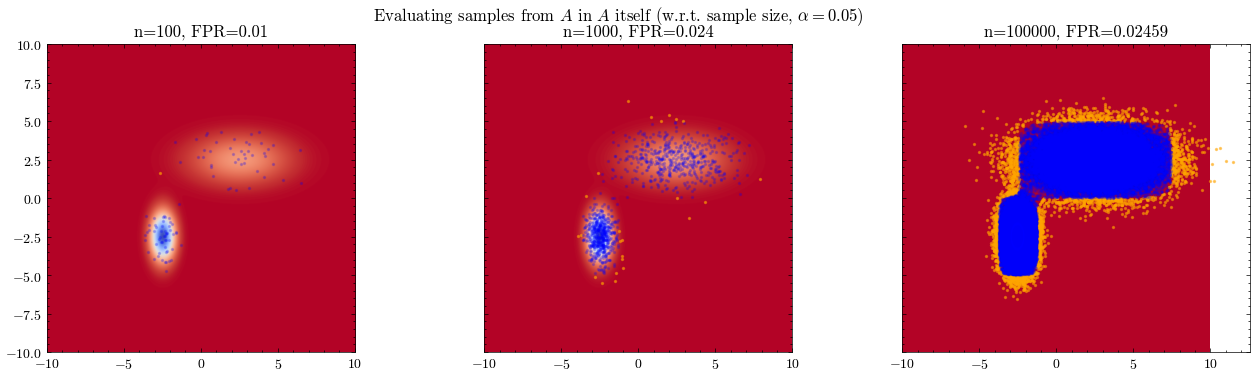

Sum Node at Root: With selection of nearest cluster at Sum Nodes (via max likelihood)


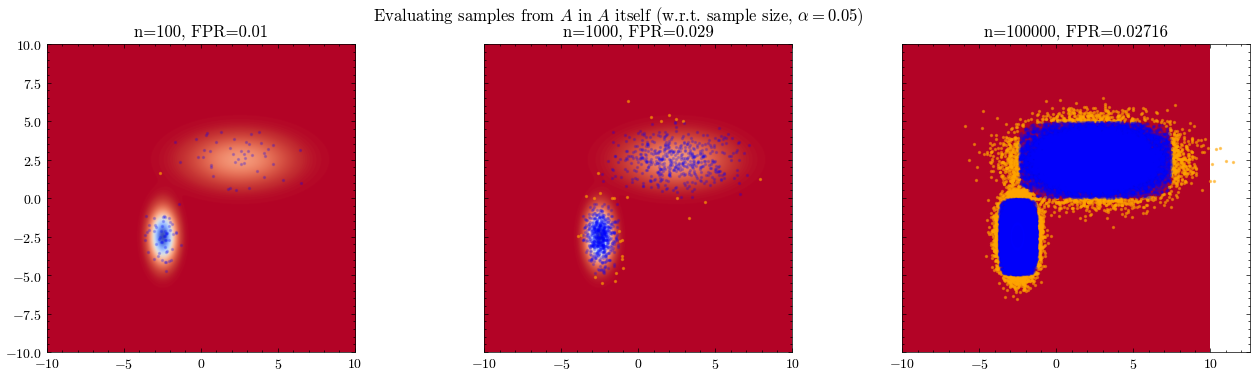

Product Node at Root


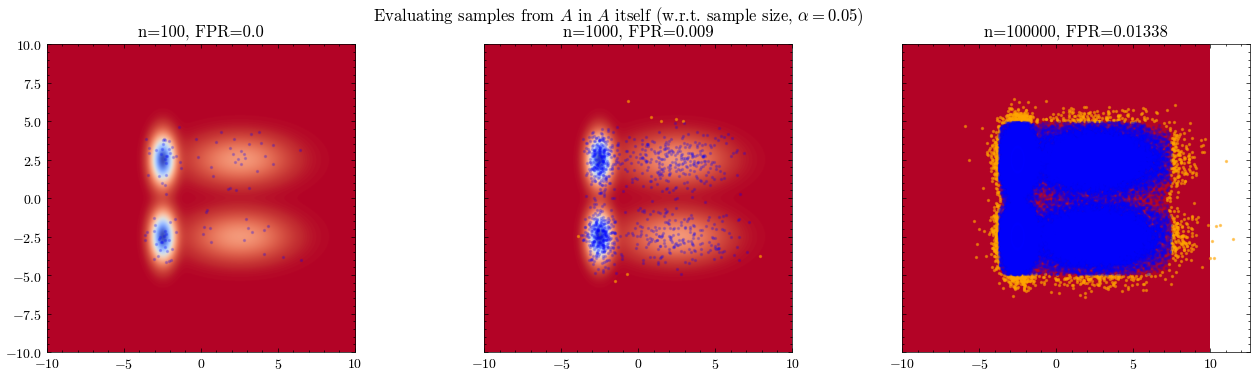

Product Node at Root: With selection of nearest cluster at Sum Nodes (via max likelihood)


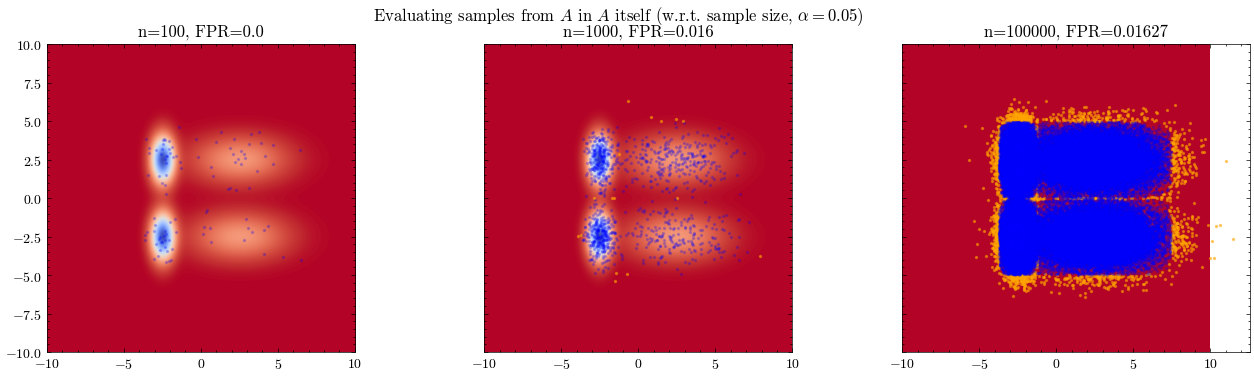

In [16]:
print("Sum Node at Root")
plot_2d_A_in_A(sumroot, alpha=0.05, n_samples=[100, 1000, 100000], grid_limit=10)
print("Sum Node at Root: With selection of nearest cluster at Sum Nodes (via max likelihood)")
plot_2d_A_in_A(sumroot, alpha=0.05, n_samples=[100, 1000, 100000], select_at_sum_nodes=True, grid_limit=10)
print("Product Node at Root")
plot_2d_A_in_A(prodroot, alpha=0.05, n_samples=[100, 1000, 100000], grid_limit=10)
print("Product Node at Root: With selection of nearest cluster at Sum Nodes (via max likelihood)")
plot_2d_A_in_A(prodroot, alpha=0.05, n_samples=[100, 1000, 100000], select_at_sum_nodes=True, grid_limit=10)

We can see two things here: 
1. Changing the order of the SPN (Sum->Prod vs Prod->Sum) inherently changes the encoded distribution (this might be obvious).
2. How the rejection "region" of the approach selecting the maximum likelihood cluster at each Sum Node changes w.r.t. averaging over all clusters. While in the given examples, the FPR of selection if higher than of averaging, it is still bounded by $\alpha$. If we would introduce more clusters and increase the distance between them, we would see that averaging might lead to an FPR exceeding $\alpha$, while the selection approach respects that boundary. Moreover, a FPR below but closer to $\alpha$ usually correlates with a higher power, as we are not overly restrictive on the resulting decision boundary.

In [17]:
def plot_2d_B_in_A(distribution_a, distribution_b_collection, alpha, n_samples=1000, select_at_sum_nodes=False, grid_limit=5.0, n_grid=1000, seed=47):

    extent = [-grid_limit, grid_limit, -grid_limit, grid_limit]
    linspace = np.linspace(-grid_limit, grid_limit, n_grid)
    X, Y = np.meshgrid(linspace, -linspace, indexing="xy")
    grid = np.dstack((X, Y)).reshape(n_grid**2, 2)

    # pvalue_grid = factorized_model.pvalues(grid).reshape(n_grid, n_grid)
    density_grid = distribution_a.pdf(grid).reshape(n_grid, n_grid)

    k = len(distribution_b_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)

    for distribution_b, ax in zip(distribution_b_collection, axes):
        # ax.imshow(pvalue_grid, cmap="coolwarm_r", extent=extent, vmin=0.0, vmax=1.0, origin="upper")
        ax.imshow(density_grid, cmap="coolwarm_r", extent=extent)

        samples_b = distribution_b.sample(n_samples=n_samples, seed=seed)
        pvalues = distribution_a.pvalues(samples_b, "two-sided", select_at_sum_nodes)
        out_of_distribution_mask = pvalues <= alpha
        ax.scatter(x=samples_b[:, 0][out_of_distribution_mask], y=samples_b[:, 1][out_of_distribution_mask], color=["orange"], alpha=0.5, label="rejected", s=2)
        ax.scatter(x=samples_b[:, 0][~out_of_distribution_mask], y=samples_b[:, 1][~out_of_distribution_mask], color=["blue"], alpha=0.2, label="not rejected", s=2)

        true_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / n_samples
        # ax.set_title(rf"$\mu_B$={distribution_b.mean()}, $\sigma_B$={distribution_b.std()}, Power={true_positive_rate}")
        ax.set_title(rf"$\mu_B$={distribution_b.mean()}, Power={true_positive_rate}")

        # ax.legend()

    fig.suptitle(f"Evaluating samples from $B$ in distribution $A$ (varying $\\theta_B$, $\\alpha={alpha}$)\n")
    plt.show()
    plt.close("all")

Sum Node at top vs. different models (both clusters with medium shifts; one cluster with large shift; Product Node at top)


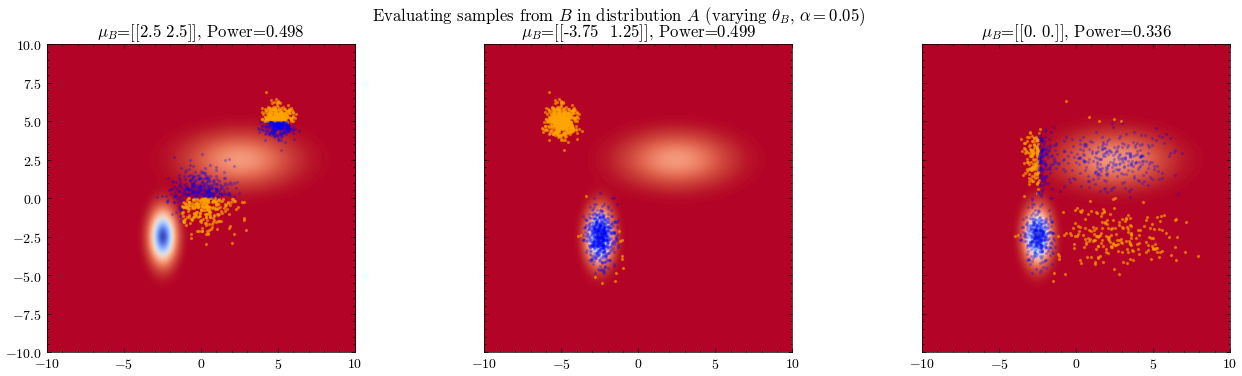

- With selection at Sum Nodes


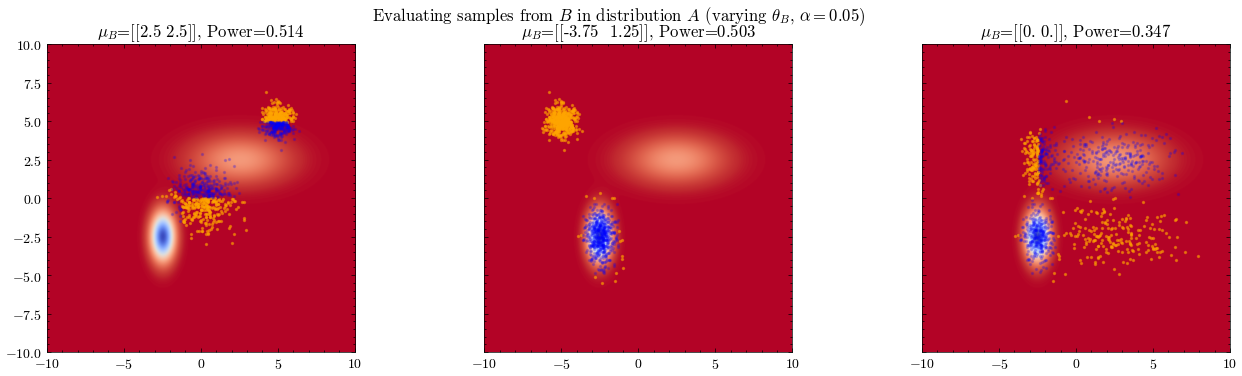

Product Node at top vs. different models (Sum Node at top; both clusters with medium shifts; one cluster with large shift)


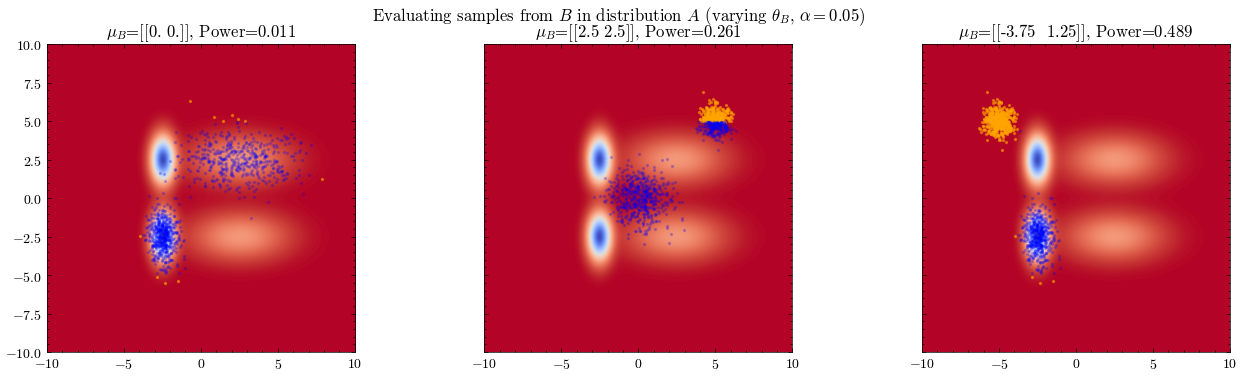

- With selection at Sum Nodes


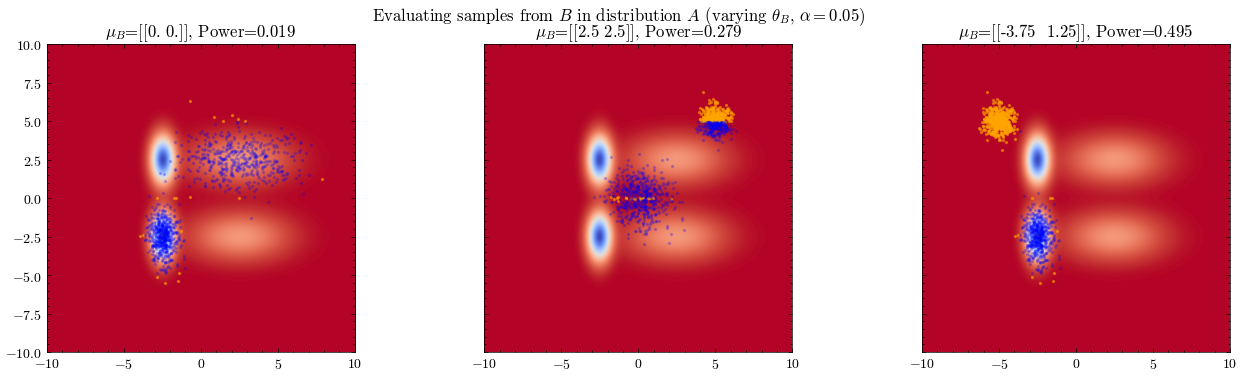

In [18]:
gx3 = GaussianLeaf(scope=[0], mu=0.0, sigma=1.0)
gy3 = GaussianLeaf(scope=[1], mu=0.0, sigma=1.0)
gx4 = GaussianLeaf(scope=[0], mu=5.0, sigma=0.5)
gy4 = GaussianLeaf(scope=[1], mu=5.0, sigma=0.5)
prod3 = ProductNode(scope=[0, 1], children=[gx3, gy3])
prod4 = ProductNode(scope=[0, 1], children=[gx4, gy4])
sumroot2 = SumNode(scope=[0, 1], children=[prod3, prod4], weights=[0.5, 0.5])
gx4b = GaussianLeaf(scope=[0], mu=-5.0, sigma=0.5)
prod4b = ProductNode(scope=[0, 1], children=[gx4b, gy4])
sumroot3 = SumNode(scope=[0, 1], children=[prod1, prod4b], weights=[0.5, 0.5])

print("Sum Node at top vs. different models (both clusters with medium shifts; one cluster with large shift; Product Node at top)")
plot_2d_B_in_A(distribution_a=sumroot, distribution_b_collection=[sumroot2, sumroot3, prodroot], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=False)
print("- With selection at Sum Nodes")
plot_2d_B_in_A(distribution_a=sumroot, distribution_b_collection=[sumroot2, sumroot3, prodroot], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=True)
print("Product Node at top vs. different models (Sum Node at top; both clusters with medium shifts; one cluster with large shift)")
plot_2d_B_in_A(distribution_a=prodroot, distribution_b_collection=[sumroot, sumroot2, sumroot3], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=False)
print("- With selection at Sum Nodes")
plot_2d_B_in_A(distribution_a=prodroot, distribution_b_collection=[sumroot, sumroot2, sumroot3], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=True)

This visualization just serves as confirmation; extending the information we have gained from the demonstrations in the univariate case above to PCs. What we now can see is that the selection approach at Sum Nodes leads to a higher Power of the test, as we do not compare observations against the entire distribution, but only the relevant local subcircuit (induced tree).  

Note: We might need follow-up experiments here that investigate the behaviour in more complex distributions, e.g. see where even selection fails.

Memo: We can now clearly see that we are testing observations, not distributions. The test cannot differentiate sumroot from prodroot (but the other way round looks slightly different!). It does not take the density of the (rejected) observations (from B) into account. Maybe, at some point, we can include this information or derive an analytic form for a distributional test.

Let's have a look at the last interesting case: We have seen that $\text{FPR}_{A(x)} > \alpha \rightarrow A \neq T$. Let's extend this idea to circuits // mixture models. Recall that we do not average the $p$-value of the children of a mixture, but select the child that yields the highest likelihood, hence which is the most probable "origin" of our observation. If the resulting $p$-values still lead to a FPR higher than alpha, then even the "most probable distribution" is the wrong one, hence our model does not accurately represent $x$. Maybe we can use this info to "re-learn" the respective child, e.g. extend this idea into "self-correction" or continual learning.

((MEMO: We could now analysze how large the sample size needs to be to conclude that $A\neq T$! Path to a distributional/one-sample/two-sample test paves itselfs here.))

<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_3848/1051654654.py:30: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  fig.suptitle(f"Evaluating samples $x\sim T$ in wrongly estimated $A$ (varying $\\theta_A$, $\\alpha={alpha}$)")


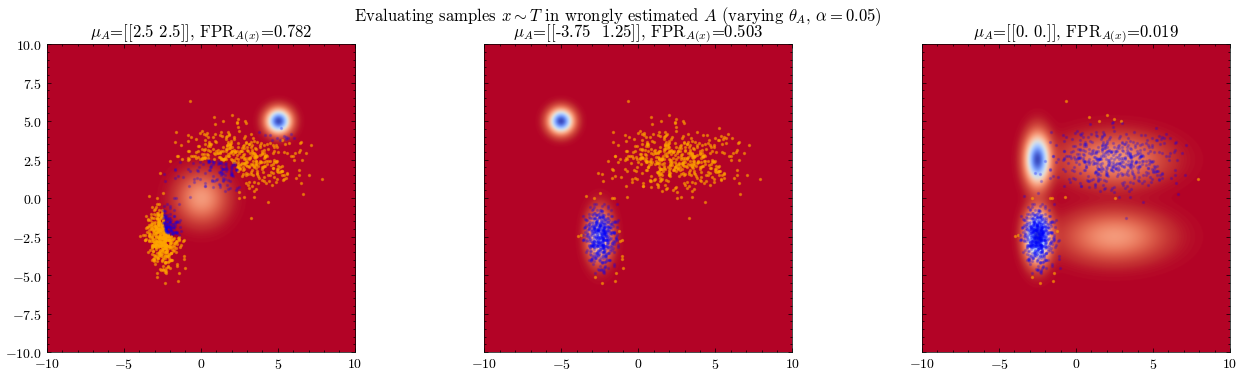

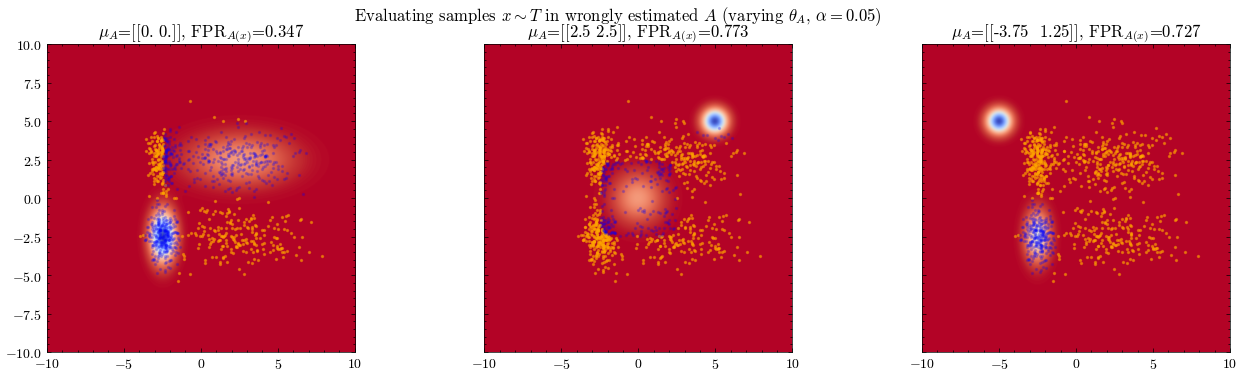

In [19]:
def plot_2d_A_neq_T(distribution_t, distribution_a_collection, alpha, n_samples=1000, select_at_sum_nodes=False, grid_limit=5.0, n_grid=1000, seed=47):

    extent = [-grid_limit, grid_limit, -grid_limit, grid_limit]
    linspace = np.linspace(-grid_limit, grid_limit, n_grid)
    X, Y = np.meshgrid(linspace, -linspace, indexing="xy")
    grid = np.dstack((X, Y)).reshape(n_grid**2, 2)

    k = len(distribution_a_collection)
    fig, axes = plt.subplots(nrows=1, ncols=k, sharey=True)
    fig.set_size_inches(16, 4)

    for distribution_a, ax in zip(distribution_a_collection, axes):
        # ax.imshow(pvalue_grid, cmap="coolwarm_r", extent=extent, vmin=0.0, vmax=1.0, origin="upper")
        density_grid = distribution_a.pdf(grid).reshape(n_grid, n_grid)
        ax.imshow(density_grid, cmap="coolwarm_r", extent=extent)

        samples_t = distribution_t.sample(n_samples=n_samples, seed=seed)
        pvalues = distribution_a.pvalues(samples_t, "two-sided", select_at_sum_nodes)
        out_of_distribution_mask = pvalues <= alpha
        ax.scatter(x=samples_t[:, 0][out_of_distribution_mask], y=samples_t[:, 1][out_of_distribution_mask], color=["orange"], alpha=0.5, label="rejected", s=2)
        ax.scatter(x=samples_t[:, 0][~out_of_distribution_mask], y=samples_t[:, 1][~out_of_distribution_mask], color=["blue"], alpha=0.2, label="not rejected", s=2)


        false_positive_rate = np.sum(out_of_distribution_mask.astype(int)) / n_samples
        fpr_tex_string = "$\\text{FPR}_{A(x)}$" 
        ax.set_title(rf"$\mu_A$={distribution_a.mean()}, {fpr_tex_string}={false_positive_rate}")

        # ax.legend()

    fig.suptitle(f"Evaluating samples $x\sim T$ in wrongly estimated $A$ (varying $\\theta_A$, $\\alpha={alpha}$)")
    plt.show()
    plt.close("all")

plot_2d_A_neq_T(distribution_t=sumroot, distribution_a_collection=[sumroot2, sumroot3, prodroot], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=True)
plot_2d_A_neq_T(distribution_t=prodroot, distribution_a_collection=[sumroot, sumroot2, sumroot3], alpha=0.05, grid_limit=10.0, select_at_sum_nodes=True)

It is of little surprise that the FPR easily exceeds $\alpha$ in most cases. There is only one little insight here: If we evaluate the samples of the original "SumRoot" circuit in the "ProdRoot" circuit (see first row, third column; both have the same leaves and only differ in the root and first layer by swapping Sums and Products), the FPR is below $\alpha$. This emphasizes that we cannot distinguish the former from the latter (however, the other way round is different; see second row, first column).  

This leads to the following proposition: We can use the relationship between the FPR and our pre-set $\alpha$ to determine if a model is wrong, but we cannot use this to know if our model is the correct one. This aligns with the principals of significance testing. We can only reject a null hypothesis, but never accept it. The next section will try to formalize this as a "loss" or a "quality" function, i.e. computing a bound that will tell us how much we are at least wrong.

#### The relationship of $\alpha$ and the FPR as a measure of model quality <a class="anchor" id="model-quality"></a>

The construction of a function representing the "quality" of a circuit w.r.t. a dataset is straightforward and the function itself rather simplistic. I propose 
$$l_{\alpha}(S||X) := \begin{cases} \text{FPR}_{S(X)} - \alpha & \text{FPR}_{S(X)}>\alpha \\ 0 & \text{else} \end{cases}$$
where $S$ is a Significance Circuit, $x$ is a dataset with the same scope as $S$. If this loss if larger than $0$, then our Significance Circuit $S$ is wrong w.r.t. $X$. Given a set of Significance Circuits $\mathcal{S}$, we can use this loss to select the best circuit $S^{\ast}$ w.r.t. $\alpha$: 
$$S^{\ast} = \arg\min_{S\in \mathcal{S}} l_{\alpha}(S||X)$$

One might be tempted to always choose the model with the lowest FPR. What we actually want is a model that respects $\alpha$, but also yields a high Power. As $\alpha$ and Power are usually correlated, the best model is the model which does not have the smallest FPR, but the FPR that is closest to $\alpha$. Thus we ensure that our probabilistic guarantees stay in place, while we aim to select the model that will perform best at identifying OOD instances.

